In [1]:
import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["JAX_ENABLE_X64"] = "True"
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']=".97"
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']="False"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'
os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
# from jax.config import config
from jax import config
# config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad
#import pyccl as ccl
import pickle as pk
import scipy.interpolate as interp
import warnings

# Suppress RuntimeWarnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import sys, os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["JAX_ENABLE_X64"] = "True"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'


# Change the current working directory to the desired path
os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
# from jax.config import config
from jax import config
# config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad
%matplotlib inline
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')



In [ ]:
import healpy as hp
# from   cosmology import *
from astropy.cosmology import FlatLambdaCDM, z_at_value
import astropy.units as u
websky_cosmo = {'Omega_M': 0.31, 'Omega_B': 0.049, 'Omega_L': 0.69, 
                                 'h': 0.68, 'sigma_8': 0.81, 'n_s':0.965}

astropy_cosmo = FlatLambdaCDM(H0=websky_cosmo['h']*100, Om0=websky_cosmo['Omega_M'])

# halo_catalogue_file = open()

h = websky_cosmo['h']
omegam = websky_cosmo['Omega_M']
rho = 2.775e11 * omegam * (h**2) # Msun/Mpc^3

f=open('/mnt/home/spandey/ceph/websky/halos.pksc')
N=np.fromfile(f,count=3,dtype=np.int32)[0]

catalog=np.fromfile(f,count=N*10,dtype=np.float32)
catalog=np.reshape(catalog,(N,10))

x  = catalog[:,0];  y = catalog[:,1];  z = catalog[:,2] # Mpc (comoving)
vx = catalog[:,3]; vy = catalog[:,4]; vz = catalog[:,5] # km/sec
R  = catalog[:,6] # Mpc



In [11]:

# convert to mass, comoving distance, radial velocity, redshfit, RA and DEc
M200m    = 4*np.pi/3.*rho*R**3        # this is M200m (mean density 200 times mean) in Msun
chi      = np.sqrt(x**2+y**2+z**2)    # Mpc
vrad     = (x*vx + y*vy + z*vz) / chi # km/sec



In [5]:
# pl.figure()
# _ = pl.hist(np.log10(M200c), bins=100, histtype='step', color='k', lw=2, range=(10,16))
# pl.yscale('log')
M200m_wh = M200m * h

# zmax = 1.5
z_array = np.linspace(0.0001, 10, 1000)
zofchi  = interp.interp1d(np.log(astropy_cosmo.comoving_distance(z_array).value), z_array, kind='cubic')

redshift = zofchi(np.log(chi))




12.081955
12.043149
12.014645
11.992606
11.974854
11.96604
11.954936
11.948316
11.9441
11.944776


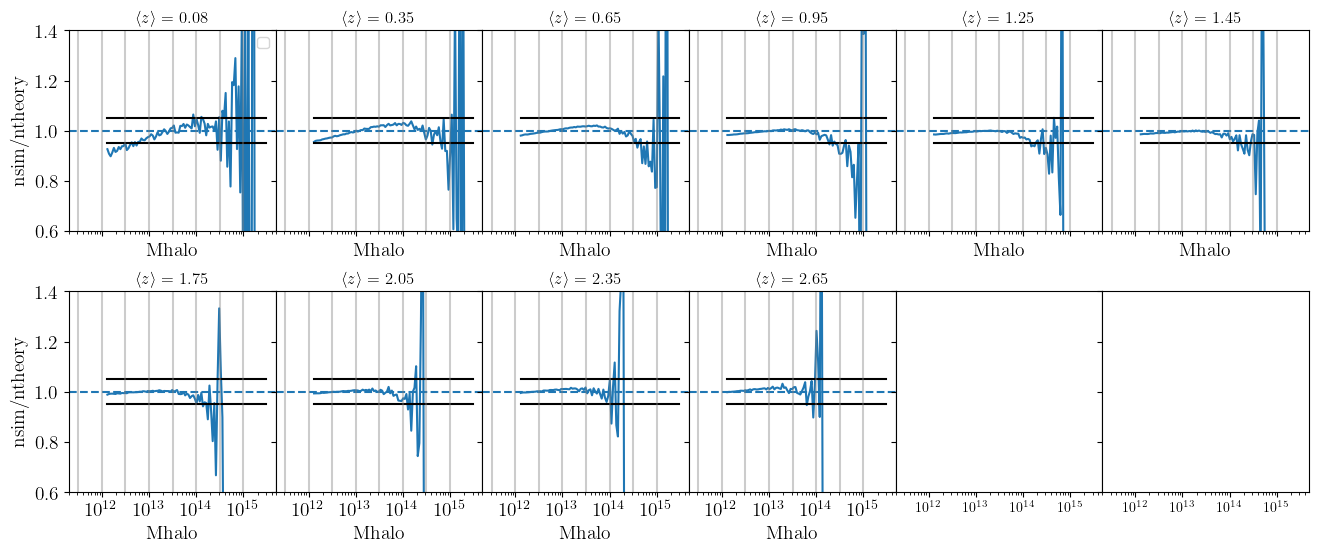

In [16]:
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.lss import mass_function
from colossus.halo import concentration
from colossus.halo import mass_defs
from scipy.ndimage.filters import gaussian_filter1d

# websky_cosmo = {'Omega_M': 0.31, 'Omega_B': 0.049, 'Omega_L': 0.69, 
                                #  'h': 0.68, 'sigma_8': 0.81, 'n_s':0.965}
params = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmology_colossus.addCosmology('myCosmo', params)
cosmology_colossus.setCosmology('myCosmo')
cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')


# min_ = np.array([0.,0.1,0.2,0.3,0.4,0.5,0.6,0.7])#,0.8,0.9,1.0,1.1,1.2,1.3])
# max_ = min_+0.1

min_ = np.array([0.,0.3,0.6,0.9,1.2,1.4,1.7,2.0, 2.3, 2.6])#,0.8,0.9,1.0,1.1,1.2,1.3])
max_ = min_+0.1



fig, ax = pl.subplots(2,int(len(min_)/2)+1, gridspec_kw = {'wspace':0., 'hspace':0.3},sharey=True,sharex=True)
fig.set_size_inches((16,6))
size_x = int(len(min_)/2)+1


dndm_model = 'tinker08'
correction = False
# mdef ='vir'
mdef ='200c'

fsky = 1

m_interp = dict()

uu=0
jj = 0
for jp in (range(len(min_))):
    mask = (redshift>min_[jp]) &  (redshift<max_[jp])
    # mhalo_sim = (10**M200c_wh[mask])
    mhalo_sim = M200m_wh[mask]

    # if correction :
    #     npart = mhalo_sim/(part_mass1).value
    #     corr = npart*(1-npart**(-0.6))
    #     mhalo_sim = corr*(part_mass1).value

    zhalo_sim = redshift[mask]
    
    

    zmean = np.mean(zhalo_sim)
    zmin, zmax = np.min(zhalo_sim), np.max(zhalo_sim)

    c200m = concentration.concentration(mhalo_sim, '200m', zmean, model = 'bhattacharya13')
    M200c, R200c, c200c = mass_defs.changeMassDefinition(mhalo_sim, c200m, zmean, '200m', '200c')


    M_array_edges = np.logspace(12.1,15.5,100)
    M_cen = 0.5*(M_array_edges[1:] + M_array_edges[:-1])
    delta_M_array = M_array_edges[1:] - M_array_edges[:-1]
    # Nm_all_sim, _ = np.histogram(mhalo_sim, bins=M_array_edges)
    Nm_all_sim, _ = np.histogram(M200c, bins=M_array_edges)
    
    print(np.amin(np.log10(mhalo_sim)))


    Rz1 = cosmo_colossus.comovingDistance(0, zmin)
    Rz2 = cosmo_colossus.comovingDistance(0, zmax)

    Vol = fsky*4/3.*np.pi*(Rz2**3-Rz1**3)



    dndm_theory = (1/M_cen) * mass_function.massFunction(M_cen, zmean,
                                                  mdef=mdef, model=dndm_model,
                                                  q_out='dndlnM')


    Nm_all_theory = dndm_theory * delta_M_array * Vol




    ax[jj,jp-uu].plot(M_cen, Nm_all_sim/Nm_all_theory) #,color='grey')
    ax[jj,jp-uu].set_ylim(0.6,1.4)

    y =  Nm_all_sim/Nm_all_theory
    ysmoothed = gaussian_filter1d(y, sigma=2)
    m_interp[zmean] = ysmoothed

    ax[jj,jp-uu].set_xscale('log')
    ax[jj,jp-uu].set_title(r'$\langle z \rangle=$ {0:2.2f}'.format(zmean))
    ax[jj,jp-uu].axhline(1.0, ls='--')
    ax[jj,jp-uu].plot(M_cen, 0.95*np.ones(len(M_cen)),color='black')
    ax[jj,jp-uu].plot(M_cen, 1.05*np.ones(len(M_cen)),color='black')


    ax[jj,jp-uu].set_xlabel(r'Mhalo',size=14)
    ax[jj,0].set_ylabel(r'nsim/ntheory', size=14)    
    ax[jj,jp-uu].tick_params(axis='both', which='major', labelsize=14)
    #ax[jj,jp-uu].axvline(part_mass.value/3.)

    ax[jj,jp-uu].axvline(10**15.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**14.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**14.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**13.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**13.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**12.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**12.0,color='grey',alpha = 0.4)
    ax[jj,jp-uu].axvline(10**11.5,color='grey',alpha = 0.4)
    ax[jj,jp-uu].tick_params(axis='both', which='minor', labelsize=14)
    if jp>(size_x-2):
        jj=1
        uu = size_x
ax[0,0].legend()
pl.show()



In [19]:
indsel = np.where((redshift>0.0) &  (redshift<2.5))[0]
M200m_wh = M200m_wh[indsel]
redshift = redshift[indsel]
vrad = vrad[indsel]
x = x[indsel]
y = y[indsel]
z = z[indsel]


4349354


In [28]:
zedges_array = np.linspace(0.0,2.5,101)
zmin_array = zedges_array[:-1]
zmax_array = zedges_array[1:]

M200c_wh = np.zeros(len(M200m_wh))
# R200c_wh = np.zeros(len(M200m_wh))
for ji in range(len(zmin_array)):
    zmin_ji = zmin_array[ji]
    zmax_ji = zmax_array[ji]
    indsel = np.where((redshift>zmin_ji) &  (redshift<zmax_ji))[0]
    # mask = (redshift>min_[jp]) &  (redshift<max_[jp])
    # mhalo_sim = (10**M200c_wh[mask])
    mhalo_sim = M200m_wh[indsel]

    zhalo_sim = redshift[indsel]
    
    zmean = np.mean(zhalo_sim)
    zmin, zmax = np.min(zhalo_sim), np.max(zhalo_sim)

    c200m = concentration.concentration(mhalo_sim, '200m', zmean, model = 'bhattacharya13')
    M200c, R200c, c200c = mass_defs.changeMassDefinition(mhalo_sim, c200m, zmean, '200m', '200c')

    M200c_wh[indsel] = M200c
    # R200c_wh[indsel] = R200c



In [29]:
ra, dec  = hp.vec2ang(np.column_stack((x,y,z)), lonlat=True)




In [30]:
nside = 512
maph   = np.zeros((hp.nside2npix(nside)))

# pix = hp.vec2pix(nside, x, y, z)
pix = hp.ang2pix(nside, ra, dec, lonlat=True)

weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(maph, pix, weight)    



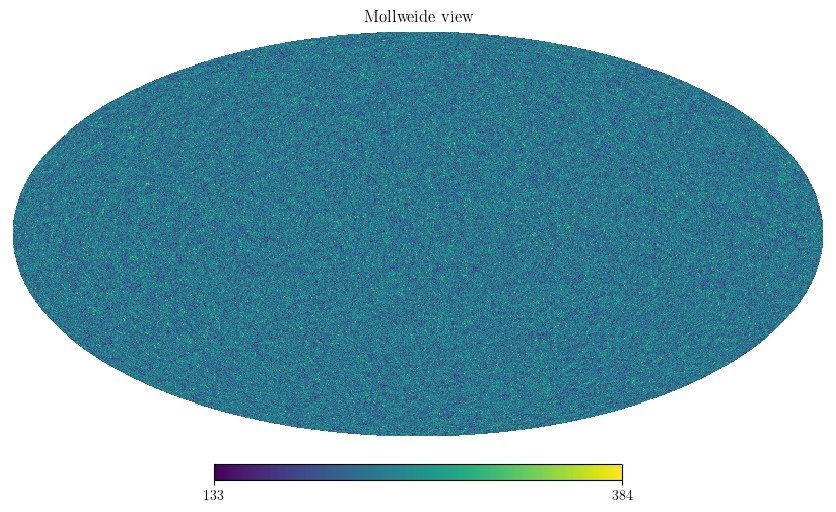

In [31]:
hp.mollview(maph)




In [33]:
# create a new astropy fits file and save the columns:
# ra, dec, z, M200c, R200c, c200c
# save the file
from astropy.io import fits
hcat_new = fits.HDUList()
cols = []
cols.append(fits.Column(name='ra', format='D', array=ra))
cols.append(fits.Column(name='dec', format='D', array=dec))
cols.append(fits.Column(name='z', format='D', array=redshift))
cols.append(fits.Column(name='M200c_wh', format='D', array=M200c_wh))
cols.append(fits.Column(name='M200m_wh', format='D', array=M200m_wh))
cols.append(fits.Column(name='vrad', format='D', array=vrad))
# cols.append(fits.Column(name='c200c', format='D', array=c200c_all))
hcat_new.append(fits.BinTableHDU.from_columns(cols))
hcat_new.writeto('/mnt/home/spandey/ceph/websky/halo_input_wM200c_zmax2p5.fits', overwrite=True)




In [34]:
# len(M200m_wh)
M200m = M200m_wh / h
indsel2 = np.where((M200m>5e13) &  (M200m<5e15))[0]
print(len(indsel2), len(M200m_wh))

from astropy.io import fits
hcat_new = fits.HDUList()
cols = []
cols.append(fits.Column(name='ra', format='D', array=ra[indsel2]))
cols.append(fits.Column(name='dec', format='D', array=dec[indsel2]))
cols.append(fits.Column(name='z', format='D', array=redshift[indsel2]))
cols.append(fits.Column(name='M200c_wh', format='D', array=M200c_wh[indsel2]))
cols.append(fits.Column(name='M200m_wh', format='D', array=M200m_wh[indsel2]))
cols.append(fits.Column(name='vrad', format='D', array=vrad[indsel2]))
# cols.append(fits.Column(name='c200c', format='D', array=c200c_all))
hcat_new.append(fits.BinTableHDU.from_columns(cols))
hcat_new.writeto('/mnt/home/spandey/ceph/websky/halo_input_wM200c_zmax2p5_minM200m_noh_5e13.fits', overwrite=True)





4349354 730217155


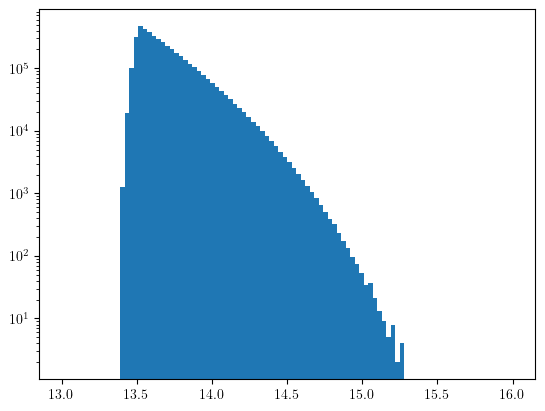

In [35]:
pl.figure()
_ = pl.hist(np.log10(M200c_wh[indsel2]), range=(13,16), bins=100)
pl.yscale('log')



In [2]:
from astropy.io import fits
df = fits.open('/mnt/home/spandey/ceph/websky/halo_input_wM200c_zmax2p5_minM200m_noh_5e13.fits')
# df[1].header
ra_all = df[1].data['ra']
dec_all = df[1].data['dec']
z_all = df[1].data['z']
M200c_all = df[1].data['M200c_wh']
M200m_all = df[1].data['M200m_wh']
vlos_all = df[1].data['vrad']
# c200c_all = df[1].data['c200c']



In [3]:
# df.keys()


In [4]:
# np.log10(5e13)
np.amin(M200m_all)

34000003399680.0

In [5]:
np.amin(np.log10(M200m_all)), np.amax(M200m_all), np.amin(z_all), np.amax(z_all)


(13.531478960467615,
 2355694535704576.0,
 0.006614628409162112,
 2.499995405517387)

In [6]:
indsel = np.where((M200m_all > 6e13) & (z_all<1.0))[0]
print(len(indsel), len(M200c_all))
ra_all = ra_all[indsel]
dec_all = dec_all[indsel]
z_all = z_all[indsel]
M200c_all = M200c_all[indsel]
vlos_all = vlos_all[indsel]



1082043 4349354


In [44]:
import healpy as hp
# create a healpy delta_halo map with the ra and dec of halos:
nside = 512
# maph   = np. zeros((hp.nside2npix(nside)))
#nside = 1024
maph   = np.zeros((hp.nside2npix(nside)))

# pix = hp.vec2pix(nside, x, y, z)
indsel = np.where((M200c_all > 2e14) & (z_all<1.0))[0]
pix = hp.ang2pix(nside, ra_all[indsel], dec_all[indsel], lonlat=True)

weight = 1. #1 for number density, array of size(x) for arbitrary
np.add.at(maph, pix, weight)
delta_h = maph/np.mean(maph) - 1


In [47]:
# np.amin((delta_h+1e-10)), np.amax((delta_h + 1e-10))
# np.amin(np.log10(1 + delta_h + 1e-10)), np.amax(np.log10(1 + delta_h))
np.amax(np.log10(2 + delta_h + 1e-10))

2.237160497586327

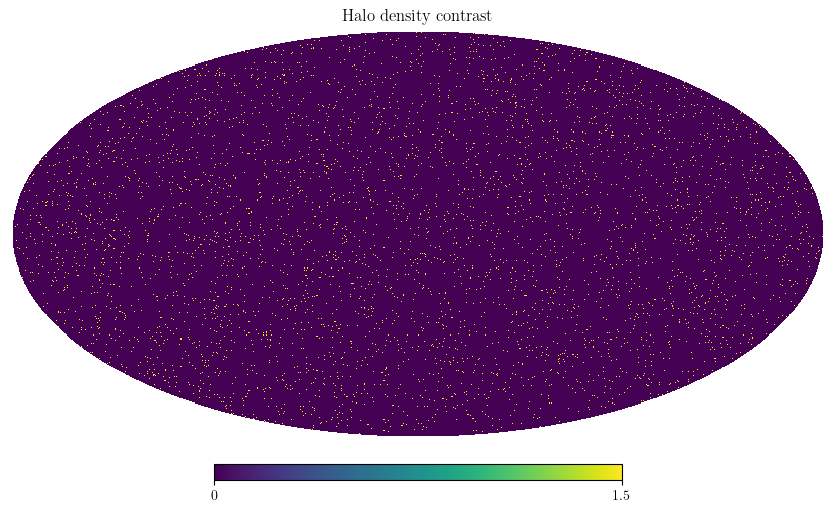

In [50]:
hp.mollview(np.log10(2 + delta_h + 1e-10), title='Halo density contrast', min=0, max=1.5)


In [51]:
import pickle as pk
import jax
import scipy.interpolate as interp
import healpy as hp
import numpy as np
from multiprocessing import Pool, cpu_count
from astropy.io import fits
import constants
import jax_cosmo.background as bkgrd
from get_sim_on_halos import get_mock_map
import h5py as h5
%load_ext autoreload
%autoreload 2

import warnings

# Suppress RuntimeWarnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# cosmo_params_dict = {'flat': True, 'H0': 67.11, 'Om0': 0.3175, 'Ob0': 0.049, 'sigma8': 0.834, 'ns': 0.9624, 'w0':-1.0}
# params = {'w0':-1.0 ,'flat': True, 'H0': 70.0, 'Om0': 0.286, 'Ob0': 0.047, 'sigma8':0.82 ,'ns': 0.96}
# params = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 5.0
sim_params_dict['delta_rhogas'] = 9.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 4.0
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.5

sim_params_dict['log10_Mc0'] = 15.1
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 0.21
sim_params_dict['nu_z'] = -5.0
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 1e-3, 18, 96
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 0.002, 2
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 3.0, 16
# halo_params_dict['z_array'] = np.array([1e-3, 0.5, 1.0])
# halo_params_dict['z_array'] = np.array([1e-3])
# halo_params_dict['z_array'] = np.array([0.5])
# halo_params_dict['z_array'] = np.array([1.0])
# halo_params_dict['nz'] = len(halo_params_dict['z_array'])
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 12.0, 15.0, 48
halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 3, 7, 24
halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**15, 64
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.01
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False

df = fits.open('/mnt/home/spandey/ceph/GODMAX/data/sim_3x2pt_simulated_DV_PKproject_values_bestfit_maglim_3x2LCDM_final.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array'] = z_array
nz_info_dict['nbins'] = 4
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
analysis_dict = {}
analysis_dict['nz_info_dict'] = nz_info_dict
analysis_dict['do_sheary'] = True
analysis_dict['do_shear2pt'] = True
analysis_dict['do_yy'] = False

df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DES_ACT_full_data_theorycov_2.5.fits')
theta_data = df_data['compton_shear'].data['ANG'][0:20]

analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 0.01
analysis_dict['want_like_diff'] = False
analysis_dict['calc_nfw_only'] = True


In [45]:


# from get_BCMP_profile import BCM_18_wP
# BCMP_test = BCM_18_wP(sim_params_dict, halo_params_dict)


# # for snap_num in snap_num_all[1:]:
# # z2chi_file = '/mnt/ceph/users/wcoulton/nbodysims/products/fiducial/100/z2chi_interp.txt'
# # z2chi = np.loadtxt(z2chi_file)
# # z2chi.shape

# # zlist_file = '/mnt/ceph/users/wcoulton/nbodysims/products/fiducial/100/zlist.txt'
# # zlist = np.loadtxt(zlist_file)
# # snap_num_all = zlist[:,0].astype(int)
# # zval_all = zlist[:,1]

# # zmax_ymap = 3.0
# # sim_number = 100
# # snap_num = 90
# # print(snap_num_all[1:-1])
# # for snap_num in snap_num_all[1:-1]:
#     # ind_snapnum = np.where(snap_num_all == snap_num)[0]
#     # zval = zval_all[ind_snapnum]
#     # if zval < zmax_ymap:
# nside = 2048    
# sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/ymap_cardinal/'
# save_ymap_fname = sdir + f'ymap_sim_test2_nside_{nside}.pkl'
# if not os.path.exists(save_ymap_fname):

#     halo_ra, halo_dec = ra_all, dec_all
#     halo_z = z_all
#     halo_m = M200c_all
#     print('number of halos: ', len(halo_m))
#     M_all = halo_m
#     ra_all = halo_ra
#     dec_all = halo_dec
#     z_all = halo_z
#     vlos_all = np.zeros_like(z_all)
#     nsel = len(M_all)

#     nh_max = 5e5
#     if nsel > nh_max:
#         num_chunks = int(np.ceil(nsel / nh_max))
#     else:
#         num_chunks = 1


#     ymap_test = np.zeros(12*nside**2)
#     for i in range(num_chunks):
#         print(f'chunk {i+1}/{num_chunks}')
#         if i == num_chunks - 1:
#             M_all_chunk = M_all[int(i*nh_max):]
#             ra_all_chunk = ra_all[int(i*nh_max):]
#             dec_all_chunk = dec_all[int(i*nh_max):]
#             z_all_chunk = z_all[int(i*nh_max):]
#             vlos_all_chunk = vlos_all[int(i*nh_max):]
#         else:
#             M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
#             ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
#             dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
#             z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
#             vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

#         mock_params_dict = {}
#         mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
#         mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
#         mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
#         mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
#         mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
#         mock_params_dict['nside'] = nside

#         halo_cat_scale_fac = 1./(1. + z_all_chunk)

#         halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(BCMP_test.cosmo_jax,halo_cat_scale_fac) * 1e9
#         mdef_delta=200
#         halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


#         halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
#         halo_cat_DA = bkgrd.angular_diameter_distance(BCMP_test.cosmo_jax,halo_cat_scale_fac)
#         max_paint_R200c_factor = 3.


#         ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
#         dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
#         z_all_np = np.array(z_all_chunk)
#         halo_cat_R200c_np = np.array(halo_cat_R200c)
#         halo_cat_DV_np = np.array(halo_cat_DA)
#         def process_halo(jhalo):
#             vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

#             nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
#             nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

#             nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

#             def hav(theta):
#                 return np.sin(theta / 2.) ** 2.

#             ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
#             ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
#             theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

#             physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

#             nearby_pix_array = np.array(nearby_pix)
#             distances_pix_array = np.array(physical_distances_jhalo)
#             logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
#             z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
#             v_los_ind_array = np.ones(len(nearby_pix)) * vlos_all_chunk[jhalo]
#             return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

#         def concatenate_results(results):
#             # Pre-compute lengths for each part
#             lengths = np.array([len(result[0]) for result in results])
#             total_length = lengths.sum()

#             # Pre-allocate arrays
#             nearby_pix_all = np.empty(total_length, dtype=int)
#             distances_pix_all = np.empty(total_length)
#             logM_ind_all = np.empty(total_length)
#             z_ind_all = np.empty(total_length)
#             v_los_ind_all = np.empty(total_length)

#             # Calculate start and end indices
#             end_ind_all = np.cumsum(lengths)
#             start_ind_all = np.roll(end_ind_all, 1)
#             start_ind_all[0] = 0

#             # Use array slicing for assignment
#             for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
#                 nearby_pix_all[start:end] = result[0]
#                 distances_pix_all[start:end] = result[1]
#                 logM_ind_all[start:end] = result[2]
#                 z_ind_all[start:end] = result[3]
#                 v_los_ind_all[start:end] = result[4]

#             return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, v_los_ind_all


#         # if __name__ == "__main__":
#         with Pool(cpu_count()) as pool:
#             results = pool.map(process_halo, range(len(z_all_chunk)))


#         nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, v_los_ind_all = concatenate_results(results)

#         mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
#         mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, v_los_ind_all]).T
#         mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
#         mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

#         mock_map_test = get_mock_map(sim_params_dict, halo_params_dict, mock_params_dict, BCMP_obj=BCMP_test)

#         # find non-finite values and set them to zero
#         ymap_test += jnp.nan_to_num(mock_map_test.ymap_final)
#         jax.clear_caches()
        


#     saved = {}
#     saved['ymap_test'] = ymap_test
#     pk.dump(saved,open(save_ymap_fname, 'wb'))







In [46]:
# hp.mollview(np.log(ymap_test))




In [47]:
# hp.mollview(np.log(ymap_test))




In [52]:
from godmax.get_B12_profile import Battaglia_12_16
B12_test = Battaglia_12_16(halo_params_dict, cosmo_params_dict)



In [49]:
# from astropy import constants as const
# import astropy.units as u

# oneMpc = (((10 ** 6)) * (u.pc).to(u.m)) * (u.m)
# sigmat = const.sigma_T
# m_e = const.m_e
# c = const.c

# coeff_kSZ = sigmat/(c)
# const_coeff_kSZ =  (((coeff_kSZ * oneMpc).to(((u.cm ** 3) / (u.km/u.s)))).value)



In [50]:
# # get the optical depth as a function of z:
# ne_bar = B12_test.cosmo_jax.OmegaB0 * B12_test.cosmo_jax.rho_c0 / m_e
# def get_tau_z(z):
#     z_array = np.linspace(0.0, z, 100)



In [53]:
jax.clear_caches()
nside = 2048
sdir = '/mnt/home/spandey/ceph/GODMAX/notebooks/mock_gen/maps_websky/'
save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
# if not os.path.exists(save_kszmap_fname):
halo_ra, halo_dec = ra_all, dec_all
halo_z = z_all
halo_m = M200c_all
# indsel = np.where((np.log10(halo_m) > 12.75))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
# indsel = np.where((halo_z < 0.95))[0]
# halo_m = halo_m[indsel]
# halo_ra = halo_ra[indsel]
# halo_dec = halo_dec[indsel]
# halo_z = halo_z[indsel]
print('number of halos: ', len(halo_m))
M_all = halo_m
ra_all = halo_ra
dec_all = halo_dec
z_all = halo_z
# vlos_all = np.zeros_like(z_all)
nsel = len(M_all)

# nh_max = 4e4
nh_max = 4e5
if nsel > nh_max:
    num_chunks = int(np.ceil(nsel / nh_max))
else:
    num_chunks = 1


tszmap_test = np.zeros(12*nside**2)
for i in range(num_chunks):
# for i in range(1):
    print(f'chunk {i+1}/{num_chunks}')
    if i == num_chunks - 1:
        M_all_chunk = M_all[int(i*nh_max):]
        ra_all_chunk = ra_all[int(i*nh_max):]
        dec_all_chunk = dec_all[int(i*nh_max):]
        z_all_chunk = z_all[int(i*nh_max):]
        vlos_all_chunk = vlos_all[int(i*nh_max):]
    else:
        M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
        ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
        dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
        z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
        vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

    mock_params_dict = {}
    mock_params_dict['halo_z'] = jnp.array(z_all_chunk)
    mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk)
    mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk)
    mock_params_dict['halo_M'] = jnp.array(M_all_chunk)
    mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk)
    mock_params_dict['nside'] = nside

    halo_cat_scale_fac = 1./(1. + z_all_chunk)

    halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax,halo_cat_scale_fac) * 1e9
    mdef_delta=200
    halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z


    halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
    halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax,halo_cat_scale_fac)
    max_paint_R200c_factor = 3.


    # ra_all_np = np.clip(np.array(ra_all_chunk), 0., 360.)
    # dec_all_np = np.clip(np.array(dec_all_chunk), -90., 90.)
    ra_all_np = np.array(ra_all_chunk)
    dec_all_np = np.array(dec_all_chunk)
    z_all_np = np.array(z_all_chunk)
    halo_cat_R200c_np = np.array(halo_cat_R200c)
    halo_cat_DV_np = np.array(halo_cat_DA)
    halo_vlos_np = np.array(vlos_all_chunk)
    def process_halo(jhalo):
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)

        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(mock_params_dict['nside'], vec, nearby_angle)

        nearby_ra, nearby_dec = hp.pix2ang(mock_params_dict['nside'], nearby_pix, lonlat=True)

        def hav(theta):
            return np.sin(theta / 2.) ** 2.

        ra1, dec1 = ra_all_np[jhalo] * np.pi / 180., dec_all_np[jhalo] * np.pi / 180.
        ra2, dec2 = nearby_ra * np.pi / 180., nearby_dec * np.pi / 180.
        theta = 2. * np.arcsin(np.sqrt(hav(dec1 - dec2) + np.cos(dec1) * np.cos(dec2) * hav(ra1 - ra2)))

        physical_distances_jhalo = halo_cat_DV_np[jhalo] * theta

        nearby_pix_array = np.array(nearby_pix)
        distances_pix_array = np.array(physical_distances_jhalo)
        logM_ind_array = np.ones(len(nearby_pix)) * np.log(M_all_chunk[jhalo])
        z_ind_array = np.ones(len(nearby_pix)) * z_all_chunk[jhalo]
        v_los_ind_array = np.ones(len(nearby_pix)) * halo_vlos_np[jhalo]
        return (nearby_pix_array, distances_pix_array, logM_ind_array, z_ind_array, v_los_ind_array, len(nearby_pix))

    def concatenate_results(results):
        # Pre-compute lengths for each part
        lengths = np.array([len(result[0]) for result in results])
        total_length = lengths.sum()

        # Pre-allocate arrays
        nearby_pix_all = np.empty(total_length, dtype=int)
        distances_pix_all = np.empty(total_length)
        logM_ind_all = np.empty(total_length)
        z_ind_all = np.empty(total_length)
        vlos_ind_all = np.empty(total_length)

        # Calculate start and end indices
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.roll(end_ind_all, 1)
        start_ind_all[0] = 0

        # Use array slicing for assignment
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            logM_ind_all[start:end] = result[2]
            z_ind_all[start:end] = result[3]
            vlos_ind_all[start:end] = result[4]

        return nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all


    # if __name__ == "__main__":
    with Pool(cpu_count()) as pool:
        results = pool.map(process_halo, range(len(z_all_chunk)))


    nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all = concatenate_results(results)

    mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
    mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
    mock_params_dict['start_ind'] = jnp.int32(jnp.array(start_ind_all))
    mock_params_dict['end_ind'] = jnp.int32(jnp.array(end_ind_all))

    mock_map_test = get_mock_map(sim_params_dict, halo_params_dict, mock_params_dict, get_ymap=True, get_kSZmap=False, BCMP_obj=B12_test)

    # find non-finite values and set them to zero
    tszmap_test += jnp.nan_to_num(mock_map_test.ymap_final)
    jax.clear_caches()
    


saved = {}
saved['tszmap_test'] = tszmap_test
pk.dump(saved,open(save_kszmap_fname, 'wb'))


# else:
#     saved = pk.load(open(save_ymap_fname, 'rb'))
#     ymap_test = saved['ymap_test']



number of halos:  1082043
chunk 1/3
chunk 2/3
chunk 3/3


In [35]:
# saved = {}
# saved['kszmap_test'] = kszmap_test
# pk.dump(saved,open(save_kszmap_fname, 'wb'))


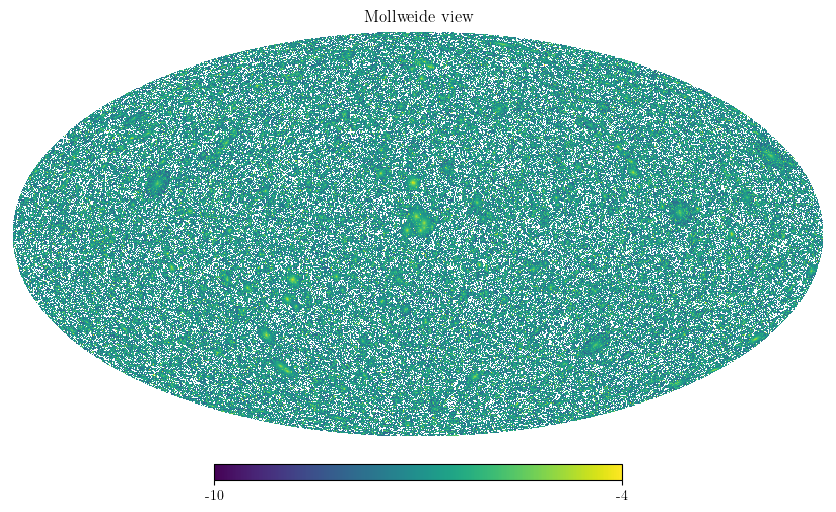

In [30]:
# import healpy as hp
# hp.mollview(np.log10(np.abs(kszmap_test)), min=-10, max=-5)
hp.mollview(np.log10(np.abs(tszmap_test)), min=-10, max=-4)
# kszmap_test
# np.amin(kszmap_test), np.amax(kszmap_test)
# mock_map_test.kszjpix_all
# mock_params_dict['pix_prop_all'].shape
# mock_map_test.tauz_array
# pl.figure()
# _ = pl.hist(vlos_ind_all, bins=100)


In [54]:
cl_tsz = hp.anafast(np.array(tszmap_test))



In [55]:
dfp = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/planck_yyauto.txt')
ellp = dfp[:,0]
Dlp = dfp[:,1]




In [56]:
# cl_ksz2_halos = hp.anafast(np.array(kszmap_test**2), np.array(delta_h))



In [14]:
# cl_kszabs_halos = hp.anafast(np.abs(np.array(kszmap_test)), np.array(delta_h))



(10, 4000)

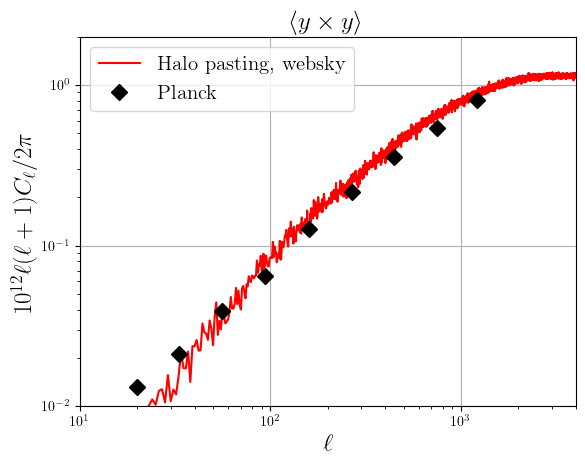

In [65]:
ell = np.arange(len(cl_tsz))
fac = 1e12 * ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_tsz, color='r', label='Halo pasting, websky')
pl.plot(ellp, Dlp, color='k', marker='D', ms=8.0, ls='', label='Planck')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
pl.yscale('log')
pl.xscale('log')
# pl.ylim(1e-14, 2e-12)
pl.ylim(0.01, 2)
pl.grid()
pl.legend(fontsize=15)
pl.xlabel(r'$\ell$', fontsize=18)
pl.ylabel(r'$10^{12} \ell(\ell+1)C_{\ell}/2\pi$', fontsize=18)
pl.title(r'$\langle y \times y \rangle$', fontsize=18)
pl.xlim(10, 4000)



(10, 4000)

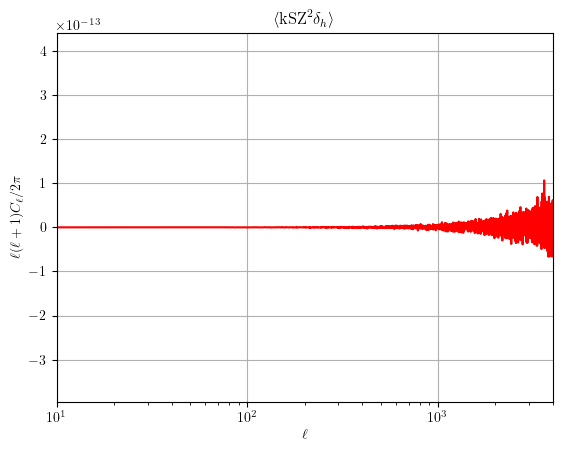

In [58]:
ell = np.arange(len(cl_ksz2_halos))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(fac * cl_ksz2_halos, color='r')
# pl.plot(fac * cl_ksz_websky / (2.725**2), color='b')
# pl.yscale('log')
pl.xscale('log')
pl.grid()
pl.xlabel(r'$\ell$')
pl.ylabel(r'$\ell(\ell+1)C_{\ell}/2\pi$')
pl.title(r'$\langle {\rm kSZ}^2 \delta_h \rangle$')
pl.xlim(10, 4000)


In [1]:
import healpy as hp
ksz_websky = hp.read_map('/mnt/home/spandey/ceph/websky/ksz.fits')




In [2]:
# np.sqrt(int(len(ksz_websky)/12))


In [ ]:
import numpy as np
ksz_websky_ud = hp.ud_grade(ksz_websky, nside_out=4096)
hp.mollview(np.log10(np.abs(ksz_websky_ud*1e-6)), min=-10, max=-5)


NameError: name 'np' is not defined

In [5]:
import numpy as np
# cl_ksz_websky = hp.anafast(np.array(ksz_websky_ud))
cl_ksz_websky = hp.anafast(np.array(ksz_websky))



In [10]:
len(cl_ksz_websky)

12288

In [8]:
import matplotlib.pyplot as pl
%matplotlib inline


In [12]:
ell = np.arange(len(cl_ksz_websky))
np.savetxt('/mnt/home/spandey/ceph/GODMAX/data/pge/ksz_autopower_webksky_muK2.txt', np.array([ell, cl_ksz_websky]).T)


(10, 12000)

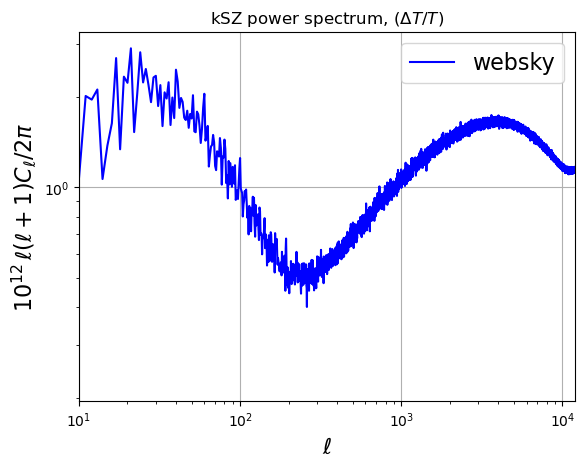

In [11]:
ell = np.arange(len(cl_ksz_websky))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
# pl.plot(1e12 * fac * cl_ksz, color='r', label='halo pasting')
pl.plot(fac * cl_ksz_websky, color='b', label='websky')
pl.yscale('log')
pl.xscale('log')
pl.grid()
pl.legend(fontsize=16)
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$10^{12} \, \ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'kSZ power spectrum, ($\Delta T/T$)')
pl.xlim(10, 12000)



(10, 4000)

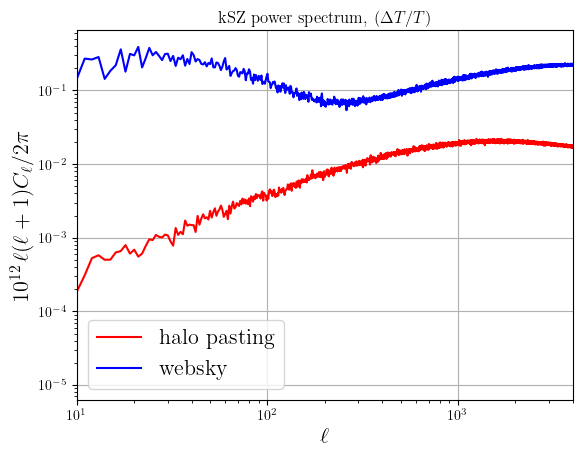

In [61]:
ell = np.arange(len(cl_ksz))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(1e12 * fac * cl_ksz, color='r', label='halo pasting')
pl.plot(fac * cl_ksz_websky / (2.725**2), color='b', label='websky')
pl.yscale('log')
pl.xscale('log')
pl.grid()
pl.legend(fontsize=16)
pl.xlabel(r'$\ell$', fontsize=16)
pl.ylabel(r'$10^{12} \, \ell(\ell+1)C_{\ell}/2\pi$', fontsize=16)
pl.title(r'kSZ power spectrum, ($\Delta T/T$)')
pl.xlim(10, 4000)



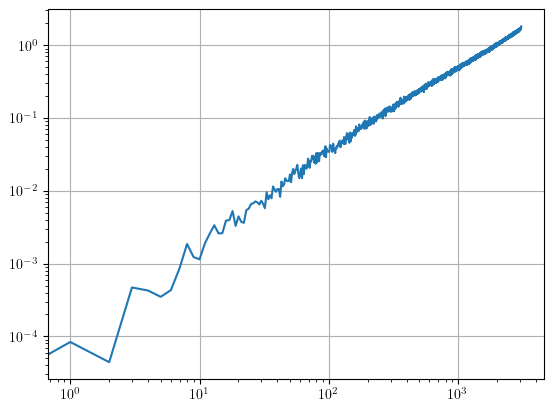

In [12]:
ell = np.arange(len(cl_ksz))
fac = ell * (ell + 1) / (2 * np.pi)
pl.figure()
pl.plot(1e12 * fac * cl_ksz)
pl.yscale('log')
pl.xscale('log')
pl.grid()


In [17]:
import pickle as pk
mask = np.ones_like(kszmap_test)
import pymaster as nmt
f_0 = nmt.NmtField(mask, [kszmap_test**2])
f_1 = nmt.NmtField(mask, [delta_h])





In [2]:
nside = 4096
b = nmt.NmtBin.from_nside_linear(nside, 96)

cl_00 = nmt.compute_full_master(f_0, f_1, b)
ell_arr = b.get_effective_ells()




NameError: name 'nmt' is not defined

In [1]:
fac = ell_arr * (ell_arr + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_arr, 1e12 * fac * cl_00[0], 'r-')
# pl.plot(ell_arr, (beam_ell**2) * fac * cl_00[0], 'r-', label='yy')
pl.loglog()
pl.grid()
pl.xlabel('$\\ell$', fontsize=16)
pl.ylabel('$10^{12} \, \ell (\ell + 1) C_\\ell / 2\pi$', fontsize=16)
# pl.legend(loc='upper right', ncol=2, labelspacing=0.1)
pl.xlim(100, 6e3)
pl.title(r'$\langle {\rm kSZ}^2 \delta_h \rangle$', fontsize=16)
# pl.ylim(1e-2, 3)
pl.show()



NameError: name 'ell_arr' is not defined

In [9]:
import jax.scipy.integrate as jsi
import jax_cosmo.background as bkgrd

mp = (1.6726219e-27*u.kg).to(u.Msun).value
mue = 1.14
RHO_CRIT_0_MPC3 = 2.77536627245708E11
cosmo_params = sim_params_dict['cosmo']
z_array = halo_params_dict['z_array']
def get_tau_z(self, jz):
    z = z_array[jz]
    z_array = jnp.linspace(0.0, z, 100)
    scale_factor_array = 1. / (1 + z_array)
    H_array = self.H0 * bkgrd.H(self.cosmo_jax, scale_factor_array)
    to_int = (1 + z_array)**2 / H_array
    tau_z = jsi.trapz(to_int, z_array)
    sigma_T = const.sigma_T.to(u.Mpc**2).value
    c = const.c.to(u.km/u.s).value
    ne_bar = cosmo_params['Ob0'] * RHO_CRIT_0_MPC3 / (mue * mp)
    val = sigma_T * ne_bar * c * tau_z
    return val




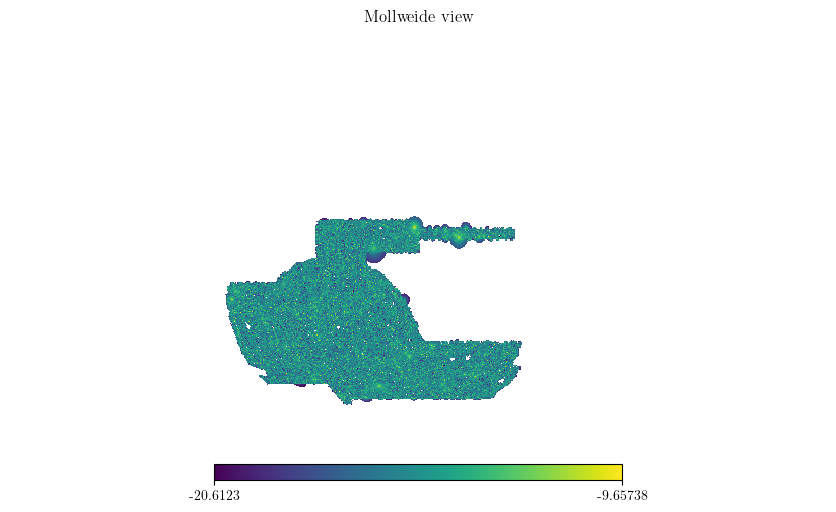

In [43]:
hp.mollview(np.log(ymap_test))




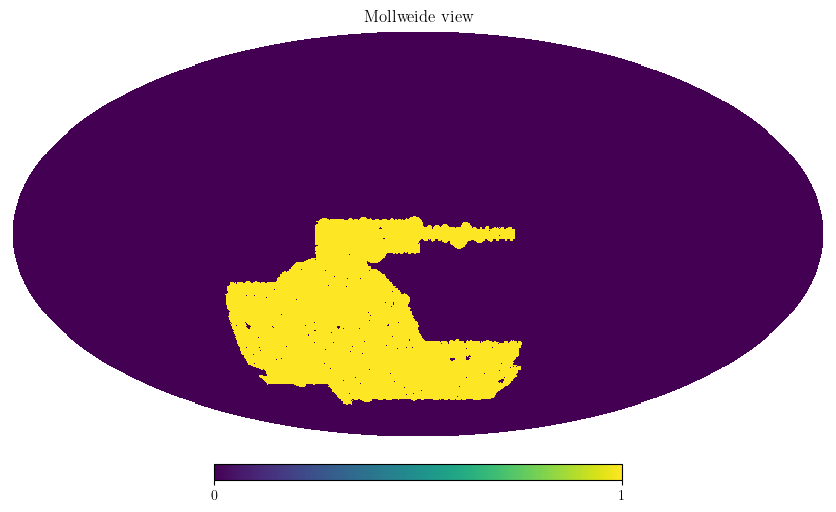

In [44]:
mask = np.zeros_like(ymap_test)
mask[ymap_test != 0] = 1
hp.mollview(mask)


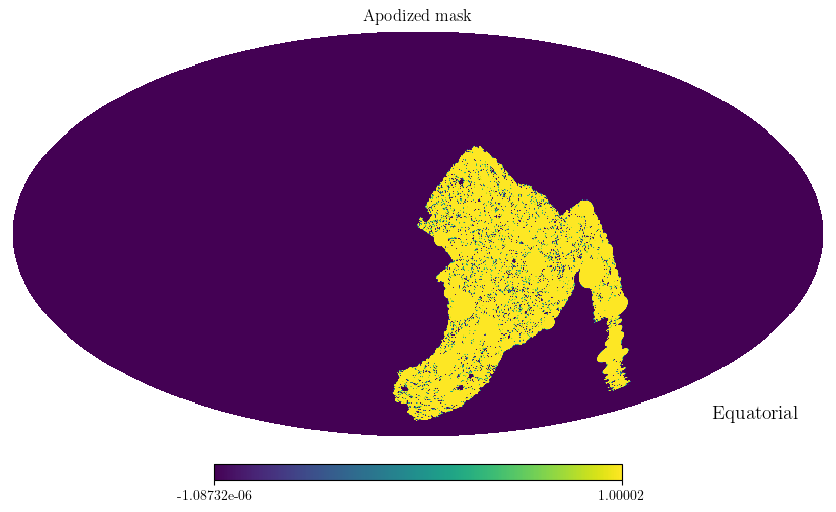

In [45]:
import pymaster as nmt

# nside = 256
mask = nmt.mask_apodization(mask,
                            0.05, apotype="Smooth")
hp.mollview(mask, coord=['G', 'C'], title='Apodized mask')
# plt.show()



In [46]:
# Read healpix maps and initialize a spin-0 and spin-2 field
f_0 = nmt.NmtField(mask, [ymap_test])
# f_2 = nmt.NmtField(mask, hp.read_map("maps.fits", field=[1, 2]))

# Initialize binning scheme with 4 ells per bandpower
b = nmt.NmtBin.from_nside_linear(nside, 16)

# Compute MASTER estimator
# spin-0 x spin-0
cl_00 = nmt.compute_full_master(f_0, f_0, b)
ell_arr = b.get_effective_ells()


In [47]:
theta_fwhm = 10.0
sigma_beam = theta_fwhm / np.sqrt(8.0 * np.log(2.0)) / 60.0 * np.pi / 180.0
beam_ell = np.exp(-0.5 * ell_arr * (ell_arr + 1) * sigma_beam**2)



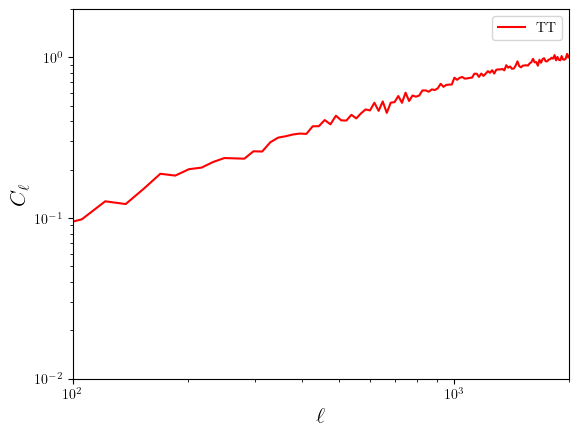

In [48]:

fac = ell_arr * (ell_arr + 1) / (2 * np.pi)
pl.figure()
pl.plot(ell_arr, 1e12 * fac * cl_00[0], 'r-', label='TT')
# pl.plot(ell_arr, (beam_ell**2) * fac * cl_00[0], 'r-', label='TT')
pl.loglog()
pl.xlabel('$\\ell$', fontsize=16)
pl.ylabel('$C_\\ell$', fontsize=16)
pl.legend(loc='upper right', ncol=2, labelspacing=0.1)
pl.xlim(100, 2e3)
pl.ylim(1e-2, 2)
pl.show()



KeyboardInterrupt: 

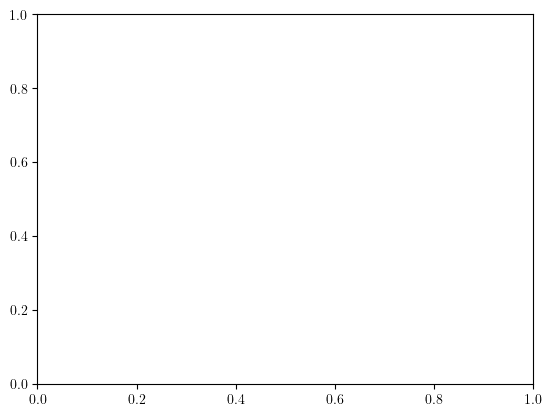

In [ ]:

# pl.figure()
# _ = pl.hist(ymap_test[indsel], bins=100, histtype='step', color='black', lw=2)



In [1]:
import jax
import jax.numpy as jnp

# Function with a string argument
def my_function(x, y, operation):
    if operation == "add":
        return x + y
    elif operation == "multiply":
        return x * y
    else:
        raise ValueError("Unsupported operation")

# Inputs for vmap
x = jnp.array([1, 2, 3])
y = jnp.array([4, 5, 6])
operation = "add"  # String extra argument

# Use vmap with in_axes
batched_function = jax.vmap(my_function, in_axes=(0, 0, None))

# Call the batched function
result = batched_function(x, y, operation)
print(result)




[5 7 9]


In [3]:
# print(result.shape)
jnp.log10(7E-4), jnp.log10(150)


(Array(-3.1549017, dtype=float32), Array(2.1760912, dtype=float32))